In [3]:
print("hello ,stock prediction")

hello ,stock prediction


In [4]:
# Stock Price Analysis

## Importing Libraries

##This section imports the required libraries for data analysis and visualization.
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
stock = yf.download("AAPL", start="2020-01-01", end="2025-01-01")
stock.head()
stock.shape
stock.info()
stock.describe()
stock.isnull().sum()
stock.columns

[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1258 non-null   float64
 1   (High, AAPL)    1258 non-null   float64
 2   (Low, AAPL)     1258 non-null   float64
 3   (Open, AAPL)    1258 non-null   float64
 4   (Volume, AAPL)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

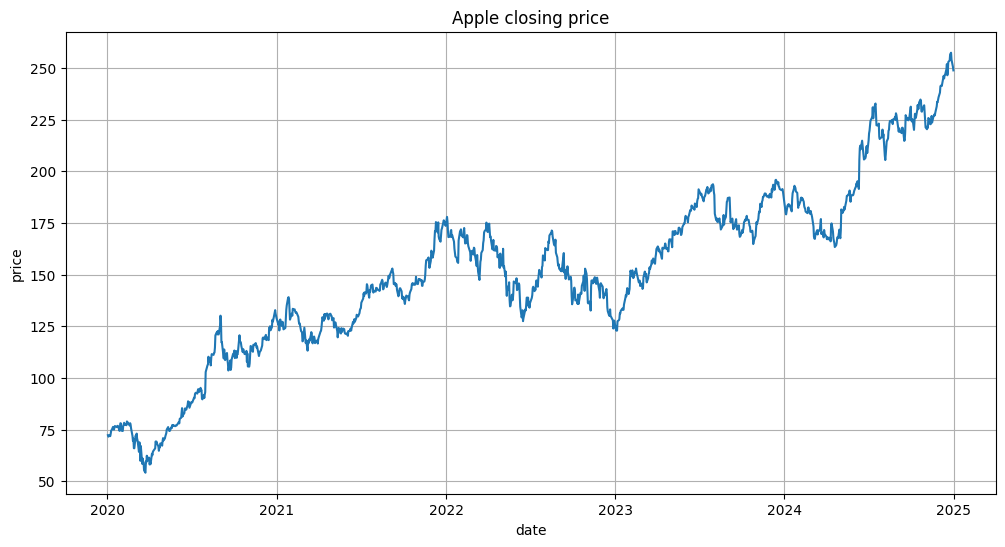

In [6]:
plt.figure(figsize=(12,6))
plt.plot(stock["Close"])
plt.title("Apple closing price")
plt.xlabel("date")
plt.ylabel("price")
plt.grid(True)
plt.show()


In [7]:
stock.corr(numeric_only=True)

,Price,Close,High,Low,Open,Volume
,Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Price,Ticker,,,,,
Close,AAPL,1.000000,0.999398,0.999395,0.998661,-0.638245
High,AAPL,0.999398,1.000000,0.999260,0.999400,-0.629894
Low,AAPL,0.999395,0.999260,1.000000,0.999401,-0.646038
Open,AAPL,0.998661,0.999400,0.999401,1.000000,-0.637840
Volume,AAPL,-0.638245,-0.629894,-0.646038,-0.637840,1.000000


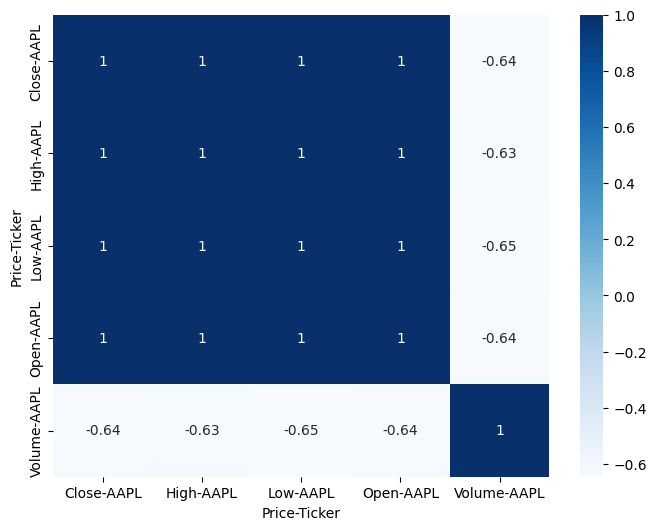

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(stock.corr(numeric_only=True),annot=True,cmap="Blues")
plt.show()

In [9]:
stock['MA10']=stock['Close'].rolling(window=10).mean()
print(stock["MA10"])

Date
2020-01-02           NaN
2020-01-03           NaN
2020-01-06           NaN
2020-01-07           NaN
2020-01-08           NaN
                 ...    
2024-12-24    249.694688
2024-12-26    250.939734
2024-12-27    251.697890
2024-12-30    252.102306
2024-12-31    252.040700
Name: MA10, Length: 1258, dtype: float64


In [10]:
stock[['Close', 'MA10']].head(15)

Price,Close,MA10
Ticker,AAPL,
Date,,
2020-01-02,72.333885,NaN
2020-01-03,71.630630,NaN
2020-01-06,72.201408,NaN
2020-01-07,71.861862,NaN
2020-01-08,73.017845,NaN
2020-01-09,74.568764,NaN
2020-01-10,74.737389,NaN
2020-01-13,76.334084,NaN


In [11]:
stock.columns = stock.columns.get_level_values(0)
stock.columns
stock["Close"]

Date
2020-01-02     72.333885
2020-01-03     71.630630
2020-01-06     72.201408
2020-01-07     71.861862
2020-01-08     73.017845
                 ...    
2024-12-24    256.560822
2024-12-26    257.375610
2024-12-27    253.967392
2024-12-30    250.598907
2024-12-31    248.830215
Name: Close, Length: 1258, dtype: float64

In [12]:
stock["MA10"] = stock["Close"].rolling(window=10).mean()

stock["MA20"] = stock["Close"].rolling(window=20).mean()

In [13]:
stock["Daily_Return"] = stock["Close"].pct_change()
stock["Prev_Close"] = stock["Close"].shift(1)
stock["Target"] = stock["Close"].shift(-1)

In [14]:
stock.dropna(inplace=True)
stock.head()

Price,Close,High,Low,Open,Volume,MA10,MA20,Daily_Return,Prev_Close,Target
Date,,,,,,,,,,
2020-01-30,77.998238,78.051221,76.765179,77.196271,126743200,76.599727,75.148353,-0.001449,78.111412,74.539879
2020-01-31,74.539879,77.711631,74.246064,77.290175,199588400,76.461730,75.258653,-0.044339,77.998238,74.335205
2020-02-03,74.335205,75.498420,72.784246,73.285174,173788400,76.219215,75.393882,-0.002746,74.539879,76.789261
2020-02-04,76.789261,76.979520,75.532118,75.936714,136616400,76.274124,75.623274,0.033013,74.335205,77.415451
2020-02-05,77.415451,78.212604,76.813371,77.913968,118826800,76.364439,75.900954,0.008155,76.789261,78.320961


In [15]:
X = stock[
    [
        "Open",
        "High",
        "Low",
        "Volume",
        "MA10",
        "MA20",
        "Daily_Return",
        "Prev_Close"
    ]
]

y = stock["Target"]
print(X.head())
print(y.head())
print(X.shape)
print(y.shape)

Price            Open       High        Low     Volume       MA10       MA20  \
Date                                                                           
2020-01-30  77.196271  78.051221  76.765179  126743200  76.599727  75.148353   
2020-01-31  77.290175  77.711631  74.246064  199588400  76.461730  75.258653   
2020-02-03  73.285174  75.498420  72.784246  173788400  76.219215  75.393882   
2020-02-04  75.936714  76.979520  75.532118  136616400  76.274124  75.623274   
2020-02-05  77.913968  78.212604  76.813371  118826800  76.364439  75.900954   

Price       Daily_Return  Prev_Close  
Date                                  
2020-01-30     -0.001449   78.111412  
2020-01-31     -0.044339   77.998238  
2020-02-03     -0.002746   74.539879  
2020-02-04      0.033013   74.335205  
2020-02-05      0.008155   76.789261  
Date
2020-01-30    74.539879
2020-01-31    74.335205
2020-02-03    76.789261
2020-02-04    77.415451
2020-02-05    78.320961
Name: Target, dtype: float64
(1238, 8)
(1

In [16]:
print(X.shape)
print(y.shape)



(1238, 8)
(1238,)


In [17]:
from sklearn.model_selection import train_test_split
split = int(len(stock) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(990, 8)
(248, 8)
(990,)
(248,)


In [18]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.16, 0.17, 0.16,..., 0.17,-0. , 0.16]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['Open','High','Low',...,'MA20','Daily_Return','Prev_Close']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.786
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


In [19]:
predictions = model.predict(X_test)
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

comparison.head(10)

,Actual,Predicted
Date,,
2024-01-05,183.483063,182.947346
2024-01-08,183.067764,183.329865
2024-01-09,184.106033,184.366341
2024-01-10,183.512772,184.563814
2024-01-11,183.839050,184.933911
2024-01-12,181.574722,184.801615
2024-01-16,180.635315,182.671459
2024-01-17,186.518707,181.805967
2024-01-18,189.415924,184.115758


In [20]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


In [21]:
mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 3.141134376806116
MSE : 16.096019747165148
RMSE: 4.011984514821206
R2 Score: 0.9752791830251064


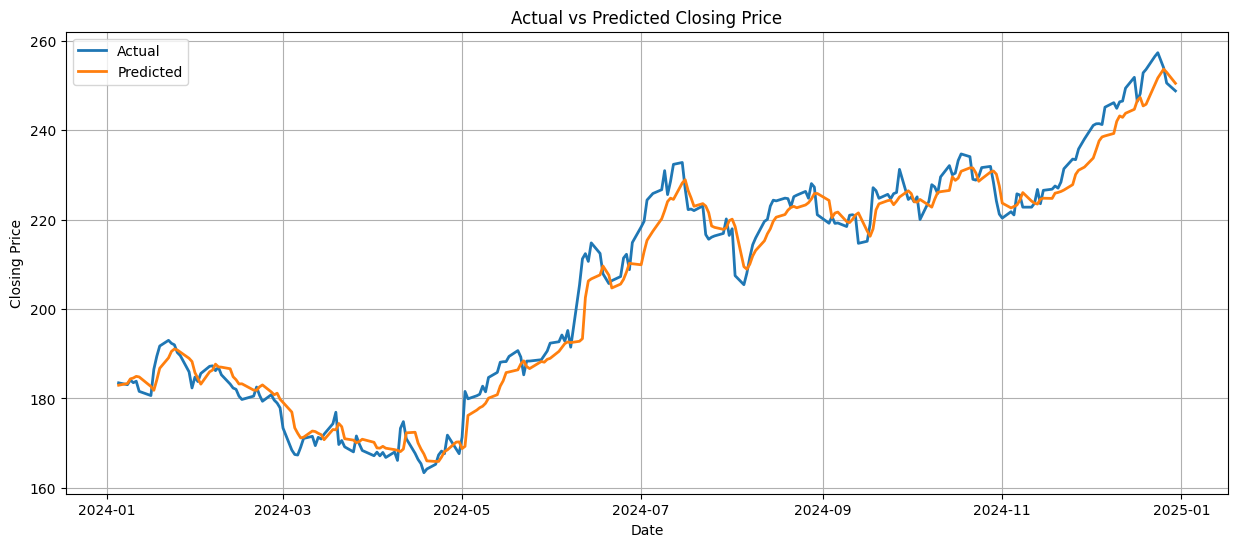

In [22]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test.index,
    y_test,
    label="Actual",
    linewidth=2
)

plt.plot(
    y_test.index,
    predictions,
    label="Predicted",
    linewidth=2
)

plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.title("Actual vs Predicted Closing Price")

plt.legend()

plt.grid(True)

plt.show()

In [35]:
import joblib
import os

save_path = os.path.join("..", "model", "stock_prediction_model.pkl")

print(save_path)

joblib.dump(model, save_path)

..\model\stock_prediction_model.pkl


['..\\model\\stock_prediction_model.pkl']

In [41]:
# ===========================
# Random Forest Regressor
# ===========================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import joblib

# Create Model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train Model
rf_model.fit(X_train, y_train)

# Predict
rf_predictions = rf_model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, rf_predictions)
mse = mean_squared_error(y_test, rf_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, rf_predictions)

# Print Results
print("========== Random Forest Regressor ==========")
print(f"MAE  : {mae}")
print(f"MSE  : {mse}")
print(f"RMSE : {rmse}")
print(f"R² Score : {r2}")

# Save Model
joblib.dump(rf_model, "../model/random_forest_model.pkl")

print("\n✅ Random Forest model saved successfully!")

# Display first 10 predictions
print("\nFirst 10 Predictions:")
print(rf_predictions[:10])

========== Random Forest Regressor ==========
MAE  : 20.20794317860757
MSE  : 735.0275329193761
RMSE : 27.111391202211962
R² Score : -0.12888039392519435

✅ Random Forest model saved successfully!

First 10 Predictions:
[179.3432988  182.19693787 182.98933212 182.83777298 182.66951492
 184.63574371 179.25805832 180.47883286 185.88203964 188.54676102]


In [42]:
sample = [[190.50, 193.20, 189.80, 55000000, 188.45, 185.90, 189.95, 0.0029]]
print(model.predict(sample))

[158.49039143]


c:\Users\bhupa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [44]:
import numpy as np

print("="*60)
print("VERIFYING STOCK PRICE PREDICTION MODEL")
print("="*60)

# 1. Feature Names
print("\n1. Feature Columns")
print(X.columns.tolist())

# 2. First 5 Rows of Features
print("\n2. First 5 Feature Rows")
print(X.head())

# 3. First 5 Target Values
print("\n3. First 5 Target Values")
print(y.head())

# 4. Close vs Target
print("\n4. Close vs Target")
print(stock[["Close", "Target"]].head(10))

# 5. Model Type
print("\n5. Loaded Model")
print(type(model))
print(model)

# 6. Test Prediction
print("\n6. Prediction Test")

sample = X_test.iloc[[0]]

print("\nSample Features:")
print(sample)

actual = y_test.iloc[0]
predicted = model.predict(sample)[0]

print("\nActual Closing Price :", actual)
print("Predicted Price      :", predicted)
print("Difference           :", abs(actual - predicted))

# 7. Random Sample Prediction
print("\n7. Another Random Sample")

index = np.random.randint(0, len(X_test))

sample2 = X_test.iloc[[index]]

actual2 = y_test.iloc[index]
predicted2 = model.predict(sample2)[0]

print("Actual    :", actual2)
print("Predicted :", predicted2)
print("Difference:", abs(actual2 - predicted2))

print("\n")
print("="*60)
print("Verification Completed")
print("="*60)

VERIFYING STOCK PRICE PREDICTION MODEL

1. Feature Columns
['Open', 'High', 'Low', 'Volume', 'MA10', 'MA20', 'Daily_Return', 'Prev_Close']

2. First 5 Feature Rows
Price            Open       High        Low     Volume       MA10       MA20  \
Date                                                                           
2020-01-30  77.196271  78.051221  76.765179  126743200  76.599727  75.148353   
2020-01-31  77.290175  77.711631  74.246064  199588400  76.461730  75.258653   
2020-02-03  73.285174  75.498420  72.784246  173788400  76.219215  75.393882   
2020-02-04  75.936714  76.979520  75.532118  136616400  76.274124  75.623274   
2020-02-05  77.913968  78.212604  76.813371  118826800  76.364439  75.900954   

Price       Daily_Return  Prev_Close  
Date                                  
2020-01-30     -0.001449   78.111412  
2020-01-31     -0.044339   77.998238  
2020-02-03     -0.002746   74.539879  
2020-02-04      0.033013   74.335205  
2020-02-05      0.008155   76.789261  

3